# Integrating ATAC, ChIP, and RNA sequencing data

## Learning objectives

- Understand the biological significance of different assays such as ATAC-seq, ChIP-seq for histone marks, DNA methylation, and RNA-seq, and how they relate to gene regulation.
- Process and integrate multi-omics data using SummarizedExperiment objects and annotation data.
- Identify and classify regulatory genomic regions (e.g., gained/lost enhancers, activated/repressed promoters) based on changes in chromatin accessibility, histone modifications, and gene expression.
- Visualize complex multi-omics data by generating heatmaps with the EnrichedHeatmap and ComplexHeatmap R packages, highlighting changes across developmental stages.
- Interpret integrated heatmaps to explore relationships between chromatin state, DNA methylation, and transcriptional output.
- Use custom functions to automate visualization workflows, adapting color scales and annotations for effective data presentation.

## Defining multi-omics regulatory states

In the [previous notebook](./05-atac_rna_integration.ipynb), we mapped the regulatory landscape using only chromatin accessibility and gene expression. Now, we will increase the biological resolution by integrating **histone modification (ChIP-seq)** data.

By overlapping ATAC-seq, RNA-seq, and specific histone marks, we can transition from generic "Active" states to highly precise biological categories, such as distinguishing a proximal active promoter from a distal active enhancer. 

Just as before, we will use a simplified, fold-change-driven approach to categorize these complex **multi-omics states**. Because our datasets were already pre-filtered for statistical significance, we will use basic logical conditions across all our different modalities, combined with **genomic distance metrics**, to assign these categories.

| Category                | ATAC | H3K4me1 | H3K27ac | H3K4me3 | H3K27me3 | RNA | Dist. to TSS | Biological interpretation                                                  | Analysis pipeline logic                                                   |
| -----------------------:|:----:|:-------:|:-------:|:-------:|:--------:|:---:|:------------:|:-------------------------------------------------------------------------- |:------------------------------------------------------------------------- |
| **Gained Enhancers**    |  ↑   |    ↑    |    ↑    | `none`  |     -    |  ↑  | >2500 bp     | Activation of a distal regulatory element driving gene expression.         | `ATAC > 0 & K4me1 > 0 & K27ac > 0 & is.na(K4me3) & RNA > 0 & dist > 2500` |
| **Lost Enhancers**      |  ↓   |    ↓    |    ↓    | `none`  |     -    |  ↓  | >2500 bp     | Deactivation of a distal enhancer, resulting in transcriptional shutdown.  | `ATAC < 0 & K4me1 < 0 & K27ac < 0 & is.na(K4me3) & RNA < 0 & dist > 2500` |
| **Active Promoters**    |  ↑   |    -    |    ↑    |    ↑    |     -    |  ↑  | <2500 bp     | Activation of a proximal promoter directly launching transcription.        | `ATAC > 0 & K27ac > 0 & K4me3 > 0 & RNA > 0 & dist < 2500`                |
| **Repressed Promoters** |  ↓   |    -    |    ↓    |    ↓    |     ↑    |  ↓  | <2500 bp     | A promoter being actively shut down via repressive Polycomb histone marks. | `ATAC < 0 & K27ac < 0 & K4me3 < 0 & K27me3 > 0 & RNA < 0 & dist < 2500`   |
_Note: In this table, `none` indicates the strict absence of the mark (which will appear as `NA` in our overlap matrix), while `-` indicates the mark's status is flexible or not strictly required for the classification._

To successfully interpret these complex multi-omic states, we must first understand the distinct biological language of each individual sequencing assay. As a quick refresher, here is exactly what each modality in our matrix measures:

| **Assay**               | **What It Measures**        | **Biological Insight**                                                      |
|:----------------------- |:--------------------------- |:--------------------------------------------------------------------------- |
| **ATAC-seq**            | Chromatin accessibility     | Identifies **open chromatin regions**, such as promoters and enhancers.     |
| **ChIP-seq (H3K4me3)**  | Active promoter mark        | Marks **active promoters**; often found at TSS (Transcription Start Sites). |
| **ChIP-seq (H3K27ac)**  | Active enhancer/promoter    | Marks **active regulatory regions**, especially enhancers.                  |
| **ChIP-seq (H3K4me1)**  | Primed or poised enhancers  | Marks **enhancers** that may be active or **poised**, not promoters.        |
| **ChIP-seq (H3K27me3)** | Repressive regions          | Marks **silenced genes** or developmental repression (Polycomb repression). |
| **DNAme (WGBS)**        | DNA methylation (CpG sites) | Typically associated with **gene silencing** and **heterochromatin**.       |
| **RNA-seq**             | Gene expression             | Final **transcriptional output**; mRNA abundance.                           |
_Note: More details can be found in the [comprehensive epigenetic analysis reference guide](../notes/epigenetic_analysis_reference_guide.md)._

Because *DNA methylation* can be a highly variable or "lagging" epigenetic mark, forcing it into rigid threshold rules can prematurely exclude interesting mechanistics. Instead of using it to define categories, we will plot the WGBS data alongside our final heatmaps to independently observe and validate how the DNA methylation landscape naturally responds to these distinct regulatory states.

## Loading packages and pre-computed data

Just as in our previous analysis, we will keep our pipeline fast and memory-efficient by strictly utilizing pre-computed datasets. 

By completely bypassing the massive, genome-wide raw `SummarizedExperiment` (`.rds`) objects, we can immediately load the exact data we need for filtering and visualization:

1. **`overlap_regulatory_status.rds`:** Our upgraded master annotation object. We will explicitly load the exact file we saved at the very end of the [previous notebook](./05-atac_rna_integration.ipynb). This is critical because it seamlessly carries over our categorized `Regulatory_State` metadata (Active, Repressed, Silenced, etc.) alongside the `logFC` stats for all our new ChIP-seq modalities.
2. **Normalized Signal Matrices (`mat_...rds`):** The pre-calculated continuous signal grids perfectly formatted for `EnrichedHeatmap` visualization.

To keep our environment clean, we won't load the fragmented individual histone mark files. Instead, we will directly load the single, consolidated `chip_matrices.rds` [master list we generated previously](./04-genomic_overlap_matrices.ipynb), which contains all our normalized matrices for every mark and timepoint in one perfectly organized object!

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  library(SummarizedExperiment)
  library(ComplexHeatmap)
  library(EnrichedHeatmap)
  library(circlize)
  library(dplyr)  # %>%, case_when(), mutate()
  library(tidyr)  # replace_na()
}))

In [2]:
overlap <- readRDS("output/overlap_regulatory_status.rds")

mat_ATAC <- readRDS("output/mat_atac.rds")
mat_RNA <- readRDS("output/mat_rna.rds")

# Instead of loading 4 fragmented individual files...
# mat_H3K4me3 <- readRDS("output/mat_h3k4me3.rds")
# mat_H3K4me1 <- readRDS("output/mat_h3k4me1.rds")
# mat_H3K27me3 <- readRDS("output/mat_h3k27me3.rds")
# mat_H3K27ac <- readRDS("output/mat_h3k27ac.rds")

# ...we can just load the entire consolidated master list
# (see 04-genomic_overlap_matrices.ipynb)
chip_matrices <- readRDS("output/chip_matrices.rds")

mat_BS <- readRDS("output/mat_bs.rds")

In [3]:
# Shows just the top-level list items without printing the massive hidden attributes
str(chip_matrices, give.attr = FALSE)

List of 8
 $ H3K27ac_11half : 'normalizedMatrix' num [1:1933, 1:100] 0.2324 0.0266 0.0239 0.0307 0.0364 ...
 $ H3K27ac_15half : 'normalizedMatrix' num [1:1933, 1:100] 0.48311 0.01757 0.00016 0.03229 0.03869 ...
 $ H3K27me3_11half: 'normalizedMatrix' num [1:1933, 1:100] 0.0603 0.0167 0.0423 0.0352 0.0313 ...
 $ H3K27me3_15half: 'normalizedMatrix' num [1:1933, 1:100] 0.03311 0.01926 0.02749 0.08658 0.00592 ...
 $ H3K4me1_11half : 'normalizedMatrix' num [1:1933, 1:100] 0.0344 0.0305 0 0.0573 0.0882 ...
 $ H3K4me1_15half : 'normalizedMatrix' num [1:1933, 1:100] 0.12863 0.028996 0.000604 0.053599 0.176741 ...
 $ H3K4me3_11half : 'normalizedMatrix' num [1:1933, 1:100] 0.7152 0 0.0556 0 0.0751 ...
 $ H3K4me3_15half : 'normalizedMatrix' num [1:1933, 1:100] 2.0519 0.0119 0.0217 0.0397 0.0515 ...


## Categorizing genomic regions by multi-omics behavior

As we established in the biological framework during our introduction, integrating histone modifications alongside chromatin accessibility and gene expression allows us to vastly increase the precision of our regulatory mapping. 

[In our previous preparation steps](./04-genomic_overlap_matrices.ipynb), we explicitly generated overlap matrices mapping all these different sequencing modalities back to our master ATAC-seq peak atlas. Because our raw input files were already strictly pre-filtered to only include statistically significant changes (`abs(logFC) >= .5` and `qvalue <= .1`), we can confidently use simple directional math (`> 0` or `< 0`) alongside the structural distance to the Transcription Start Site (`distanceToTSS`) to define our complex biological signatures.

### Mathematical cleanup (Handling missing values)

Before we assign these multi-omics categories, we must apply a highly targeted mathematical cleanup. In R, evaluating `NA > 0` returns `NA` rather than `FALSE`, which can silently corrupt complex filtering chains. To prevent this, any missing `NA` values *specifically within our `logFC` columns* will be safely converted to `0`, ensuring our directional math executes flawlessly. We deliberately leave the `annotation` columns untouched so we can still use `is.na()` to formally check for the strict absence of specific physical overlaps (such as ruling out the H3K4me3 promoter mark when defining distal enhancers).

In [4]:
# # Identify all column indices that contain the string "logFC"
# logFC_cols <- grep("logFC", names(mcols(overlap)))

# # Replace all NA values with 0 in those specific columns
# mcols(overlap)[logFC_cols] <- lapply(mcols(overlap)[logFC_cols], function(x) {
#   replace(x, is.na(x), 0)
# })

# Extract metadata, clean it with dplyr, and assign it right back to the GRanges object
mcols(overlap) <- as.data.frame(mcols(overlap)) %>%
  mutate(across(contains("logFC"), ~ replace_na(.x, 0)))

In [5]:
# First few rows of the pre-processed GRanges object
print(head(overlap[, c("ATAC_logFC", "RNA_logFC")], 10))

GRanges object with 10 ranges and 2 metadata columns:
          seqnames          ranges strand | ATAC_logFC RNA_logFC
             <Rle>       <IRanges>  <Rle> |  <numeric> <numeric>
   peak_1     chr1 3670547-3672665      * |   0.602984   1.37498
   peak_2     chr1 4332510-4332710      * |   0.855748   0.00000
   peak_3     chr1 4491755-4492573      * |  -0.620926   0.00000
   peak_4     chr1 4571186-4572423      * |  -0.511046   0.00000
   peak_5     chr1 4785062-4786325      * |   0.540908   0.00000
   peak_6     chr1 5232000-5233386      * |  -2.501780   0.00000
   peak_7     chr1 5587862-5589288      * |  -0.596064   2.81715
   peak_8     chr1 6358864-6359863      * |  -0.913905   0.00000
   peak_9     chr1 6734526-6735054      * |  -0.918568  -2.16727
  peak_10     chr1 7313422-7313895      * |  -3.295645   0.00000
  -------
  seqinfo: 21 sequences from an unspecified genome; no seqlengths


### Defining strict biological states

We then execute an advanced filtering logic to strictly annotate every peak into one of four precise states:

- **Gained Enhancers:** Distal elements (> 2.5kb from a TSS) that gain chromatin accessibility (ATAC is higher in E15.5 than E11.5), gain activating enhancer marks (H3K4me1, H3K27ac), strictly lack promoter marks (H3K4me3), and successfully drive increased gene expression.
- **Lost Enhancers:** Distal elements that lose both accessibility (ATAC is lower in E15.5 than E11.5) and activating histone marks, resulting in the transcriptional shutdown of their associated genes.
- **Active Promoters:** Proximal elements (< 2.5kb from a TSS) that gain accessibility (ATAC is higher in E15.5 than E11.5) and powerful active promoter marks (H3K4me3, H3K27ac) to directly launch transcription.
- **Repressed Promoters:** Proximal elements that lose accessibility (ATAC is lower in E15.5 than E11.5) and active marks, while explicitly gaining the Polycomb repressive mark (H3K27me3) to securely and stably silence transcription.

To do this, we will use `dplyr::case_when()` to create a pure, strict `Multiomics_State` column. Any peak that does not mathematically meet these rigorous criteria will default to `"Unclassified"`.

In [6]:
mcols(overlap) <- as.data.frame(mcols(overlap)) %>%
  mutate(
    # Create a NEW column (preserving the original Regulatory_State column)
    Multiomics_State = case_when(

      # Gained Enhancers
      ATAC_logFC > 0 & 
        ATAC_distanceToTSS > 2500 & 
        H3K4me1_logFC > 0 & 
        H3K27ac_logFC > 0 & 
        is.na(H3K4me3_annotation) & 
        RNA_logFC > 0 
      ~ "Gained Enhancers",
      
      # Lost Enhancers
      ATAC_logFC < 0 & 
        ATAC_distanceToTSS > 2500 & 
        H3K4me1_logFC < 0 & 
        H3K27ac_logFC < 0 & 
        is.na(H3K4me3_annotation) & 
        RNA_logFC < 0 
      ~ "Lost Enhancers",
      
      # Active Promoters
      ATAC_logFC > 0 & 
        ATAC_distanceToTSS < 2500 & 
        H3K4me3_logFC > 0 & 
        H3K27ac_logFC > 0 & 
        RNA_logFC > 0 
      ~ "Active Promoters",
      
      # Repressed Promoters
      ATAC_logFC < 0 & 
        ATAC_distanceToTSS < 2500 & 
        H3K4me3_logFC < 0 & 
        H3K27ac_logFC < 0 & 
        H3K27me3_logFC > 0 & 
        RNA_logFC < 0 
      ~ "Repressed Promoters",
      
      # If a region doesn't match our strict rules, leave it unclassified
      .default = "Unclassified"
    )
  )

In [7]:
# First few rows of the final overlap object
print(overlap[1:15, c("Regulatory_State", "Multiomics_State")])

GRanges object with 15 ranges and 2 metadata columns:
          seqnames          ranges strand | Regulatory_State Multiomics_State
             <Rle>       <IRanges>  <Rle> |      <character>      <character>
   peak_1     chr1 3670547-3672665      * |           Active Active Promoters
   peak_2     chr1 4332510-4332710      * |        Inc. Acc.     Unclassified
   peak_3     chr1 4491755-4492573      * |        Dec. Acc.     Unclassified
   peak_4     chr1 4571186-4572423      * |        Dec. Acc.     Unclassified
   peak_5     chr1 4785062-4786325      * |        Inc. Acc.     Unclassified
      ...      ...             ...    ... .              ...              ...
  peak_11     chr1 8410409-8410976      * |      Incongruent     Unclassified
  peak_12     chr1 8913622-8914181      * |      Incongruent     Unclassified
  peak_13     chr1 8948294-8948530      * |      Incongruent     Unclassified
  peak_14     chr1 9298449-9300284      * |           Active Active Promoters
  peak_15 

### The reality of multi-omics strictness

If we look at the results above, we see that the vast majority of the peaks are labeled `"Unclassified"`. This is exactly what we expect biologically!

Our rules are very strict; for a region to be an `Active Promoter`, it must simultaneously gain ATAC, RNA, H3K4me3, *and* H3K27ac. If even one of those marks fails to pass our significance thresholds, the entire chain breaks. This perfectly highlights a core biological reality: **most of the genome does not undergo perfectly coordinated changes across 5 different sequencing assays simultaneously.** The relatively few regions that do survive this filtering are the absolute "gold standard" regulatory elements driving development.

### Hierarchy collapsing for visualization

When we plot our final massive heatmap, we want a single, clean layout that pulls out our elite Promoters and Enhancers at the top, while still displaying the generically "Active" or "Repressed" genomic background below them.

If we ask `ComplexHeatmap` to split the rows using our current column, it will group the majority of the genome into one massive, uninformative `"Unclassified"` block, and we will lose all the ATAC/RNA patterns we discovered in the previous notebook. Conversely, if we try to feed the heatmap *both* columns separately, it will mathematically multiply them into 20+ visually fractured micro-slices.

To solve this, we decide to execute a data science trick: **Hierarchy Collapsing**. We will run our logic one more time, but this time, if a peak fails the strict ChIP-seq test, we will tell it to dynamically inherit its old `Regulatory_State` label.

In [8]:
# Execute the logic again, but this time using the fallback **Hierarchy Collapsing**
mcols(overlap) <- as.data.frame(mcols(overlap)) %>%
  mutate(
    # Create a NEW column (preserving the original Regulatory_State column)
    Multiomics_State = case_when(

      # Gained Enhancers
      ATAC_logFC > 0 & 
        ATAC_distanceToTSS > 2500 & 
        H3K4me1_logFC > 0 & 
        H3K27ac_logFC > 0 & 
        is.na(H3K4me3_annotation) & 
        RNA_logFC > 0 
      ~ "Gained Enhancers",
      
      # Lost Enhancers
      ATAC_logFC < 0 & 
        ATAC_distanceToTSS > 2500 & 
        H3K4me1_logFC < 0 & 
        H3K27ac_logFC < 0 & 
        is.na(H3K4me3_annotation) & 
        RNA_logFC < 0 
      ~ "Lost Enhancers",
      
      # Active Promoters
      ATAC_logFC > 0 & 
        ATAC_distanceToTSS < 2500 & 
        H3K4me3_logFC > 0 & 
        H3K27ac_logFC > 0 & 
        RNA_logFC > 0 
      ~ "Active Promoters",
      
      # Repressed Promoters
      ATAC_logFC < 0 & 
        ATAC_distanceToTSS < 2500 & 
        H3K4me3_logFC < 0 & 
        H3K27ac_logFC < 0 & 
        H3K27me3_logFC > 0 & 
        RNA_logFC < 0 
      ~ "Repressed Promoters",
      
      # FALLBACK: inherit the generic label instead of "Unclassified"
      .default = Regulatory_State
    )
  )

In [9]:
# First few rows of the updated final overlap object
print(overlap[1:15, c("Regulatory_State", "Multiomics_State")])

GRanges object with 15 ranges and 2 metadata columns:
          seqnames          ranges strand | Regulatory_State Multiomics_State
             <Rle>       <IRanges>  <Rle> |      <character>      <character>
   peak_1     chr1 3670547-3672665      * |           Active Active Promoters
   peak_2     chr1 4332510-4332710      * |        Inc. Acc.        Inc. Acc.
   peak_3     chr1 4491755-4492573      * |        Dec. Acc.        Dec. Acc.
   peak_4     chr1 4571186-4572423      * |        Dec. Acc.        Dec. Acc.
   peak_5     chr1 4785062-4786325      * |        Inc. Acc.        Inc. Acc.
      ...      ...             ...    ... .              ...              ...
  peak_11     chr1 8410409-8410976      * |      Incongruent      Incongruent
  peak_12     chr1 8913622-8914181      * |      Incongruent      Incongruent
  peak_13     chr1 8948294-8948530      * |      Incongruent      Incongruent
  peak_14     chr1 9298449-9300284      * |           Active Active Promoters
  peak_15 

In [10]:
# Saving the whole final project overlap SE object
saveRDS(object = overlap, file = "output/overlap_multiomics_state.rds")

## Visualizing the complete multi-omics landscape

### Preparing the continuous ATAC, ChIP and WGBS block

Now that every peak in our dataset has been assigned a precise, hierarchical multi-omics state, we can render the final composite figure. To do this, we will aggressively reuse the `custom_enrichedheatmap_plotting()` wrapper function we built previously. 

We will simply pass it our newly loaded `chip_matrices` and `mat_bs` objects to rapidly generate heatmaps for all **12 continuous sequencing modalities** (ATAC, H3K4me3, H3K4me1, H3K27me3, H3K27ac, and DNA Methylation). To maintain strict visual consistency across the entire course, we will also explicitly reuse the exact same track colors (e.g., Red for ATAC, Green for H3K4me3) and layout parameters we established for these assays in our earlier notebooks!

In [11]:
# Load our custom multi-omics plotting tool from the external script
source("scripts/custom_enrichedheatmap_plotting.R")

Because we are plotting a massive 14-column figure in this notebook, we need to strictly constrain the physical dimensions of every single heatmap to fit on the page (e.g., width = 2 cm, height = 8 cm, and top annotation height = 1 cm).

While we *could* permanently change the default arguments inside our `custom_enrichedheatmap_plotting.R` script, doing so is generally considered bad practice. That script is a shared utility used across our entire project (including Notebooks 03 and 05). If we hardcode fixed centimeter dimensions into the master script now, we risk breaking the layouts of our older notebooks, which rely on flexible proportional scaling (`unit(1, "null")`).

Instead, we will use a **local wrapper**; we will define a tiny, temporary function in the current notebook that passes our data down to the master script, but "bakes in" our specific dimensions. This allows us to rapidly generate all 12 ChIP/ATAC/WGBS heatmaps without copying and pasting the dimension arguments 12 times.

In [12]:
# Create a local wrapper to safely lock in our specific layout dimensions
make_EH <- function(...) {
  custom_enrichedheatmap_plotting(
    ...,  # Passes all the unique arguments (e.g., norm_mat, hm_name) straight through
    hm_width = unit(2, "cm"), 
    hm_height = unit(8, "cm"), 
    top_anno_height = unit(1, "cm"), 

    # Aesthetic fine-tuning
    title_fontsize = 8, 
    axis_fontsize = 7, 
    axis_lwd = 0.4
  )
}

In [13]:
# ATAC heatmaps
# (See notebook 05-atac_rna_integration.ipynb)
eh_atac_11h <- make_EH(
  norm_mat = mat_ATAC$ATAC_11half, 
  hm_name = "AS-E11.5", col_fill = "pink")

eh_atac_15h <- make_EH(
  norm_mat = mat_ATAC$ATAC_15half, 
  hm_name = "AS-E15.5", col_fill = "paleturquoise")

In [14]:
# H3K4me3 heatmaps
# (See notebook 03-chip_rna_visualization.ipynb)
eh_h3k4me3_11h <- make_EH(
  norm_mat = chip_matrices$H3K4me3_11half, 
  hm_name = 'K4me3-E11.5', col_fill = 'pink', 
  heatmap_cols = c('white', 'darkgreen'))

eh_h3k4me3_15h <- make_EH(
  norm_mat = chip_matrices$H3K4me3_15half, 
  hm_name = 'K4me3-E15.5', col_fill = 'paleturquoise', 
  heatmap_cols = c('white', 'darkgreen'))

In [15]:
# H3K4me1 heatmaps
# (See notebook 03-chip_rna_visualization.ipynb)
eh_h3k4me1_11h <- make_EH(
  norm_mat = chip_matrices$H3K4me1_11half, 
  hm_name = 'K4me1-E11.5', col_fill = 'pink',
  heatmap_cols = c('white', 'darkblue'))

eh_h3k4me1_15h <- make_EH(
  norm_mat = chip_matrices$H3K4me1_15half, 
  hm_name = 'K4me1-E15.5', col_fill = 'paleturquoise', 
  heatmap_cols = c('white', 'darkblue'))

In [16]:
# H3K27me3 heatmaps
# (See notebook 03-chip_rna_visualization.ipynb)
eh_h3k27me3_11h <- make_EH(
  norm_mat = chip_matrices$H3K27me3_11half, 
  hm_name = 'K27me3-E11.5', col_fill = 'pink', 
  heatmap_cols = c('white', 'darkorchid'))

eh_h3k27me3_15h <- make_EH(
  norm_mat = chip_matrices$H3K27me3_15half, 
  hm_name = 'K27me3-E15.5', col_fill = 'paleturquoise', 
  heatmap_cols = c('white', 'darkorchid'))

In [17]:
# H3K27ac heatmaps
# (See notebook 03-chip_rna_visualization.ipynb)
eh_h3k27ac_11h <- make_EH(
  norm_mat = chip_matrices$H3K27ac_11half, 
  hm_name = 'K27ac-E11.5', col_fill = 'pink', 
  heatmap_cols = c('white', 'darkred'))

eh_h3k27ac_15h <- make_EH(
  norm_mat = chip_matrices$H3K27ac_15half, 
  hm_name = 'K27ac-E15.5', col_fill = 'paleturquoise',
  heatmap_cols = c('white', 'darkred'))

In [18]:
# WGBS heatmaps
# (See notebook 04-genomic_overlap_matrices.ipynb)
eh_wgbs_11h <- make_EH(
  norm_mat = mat_BS$WGBS_11half, 
  hm_name = 'WGBS-E11.5', col_fill = 'pink', 
  heatmap_cols = c("red", "white", "blue"))

eh_wgbs_15h <- make_EH(
  norm_mat = mat_BS$WGBS_15half, 
  hm_name = 'WGBS-E15.5', col_fill = 'paleturquoise', 
  heatmap_cols = c("red", "white", "blue"))

### Preparing the discrete RNA-seq block

Because RNA-seq is measured in discrete counts per gene rather than continuous genomic coverage, it bypasses our `EnrichedHeatmap` wrapper. We simply construct it as a standard `ComplexHeatmap` block, setting `cluster_rows = FALSE` so it perfectly maps onto the ATAC peak coordinates.

In [19]:
# RNA heatmap (ComplexHeatmap)
# (See notebook 05-atac_rna_integration.ipynb)
set.seed(100)

rna_groups <- ifelse(grepl("11half", colnames(mat_RNA)), "E11.5", "E15.5")

rna_hm <- Heatmap(
  matrix = mat_RNA, 
  cluster_columns = FALSE, 
  cluster_rows = FALSE, 
  show_row_names = FALSE, 
  show_column_names = FALSE, 
  show_row_dend = FALSE, 
  na_col = "#c0c0c0",
  width = unit(2, "cm"), height = unit(18, "cm"), 
  top_annotation = HeatmapAnnotation(
    group = rna_groups, 
    col = list(group = c("E11.5" = "#ff00ff", "E15.5" = "#adff2f")), 
    show_annotation_name = FALSE), 
  heatmap_legend_param = list(
    at = scales::pretty_breaks(n = 2)(
      range(mat_RNA, na.rm = TRUE)),
    labels_gp = gpar(fontsize = 7),  # To match those of other EnrichedHeatmaps
    title = "log2(FC)"))

### Preparing the hierarchical row splits

To divide our massive heatmap, we will extract our newly merged `Multiomics_State` column. We will convert it into a formal R `factor`, which allows us to explicitly define the top-to-bottom visual rendering order. This ensures our elite "Active Promoters" and "Gained Enhancers" sit prominently at the top of the figure.

In [20]:
# Extract our new merged hierarchical column
split_multiomics <- overlap$Multiomics_State

# Explicitly order the biological categories for the visual split
# (Ensure the names exactly match the strings in the Multiomics_State column!)
biological_order <- c(
  "Active Promoters", "Gained Enhancers", "Active", "Inc. Acc.", 
  "Repressed Promoters", "Lost Enhancers", "Repressed", "Dec. Acc.", 
  "Silenced", "Incongruent")

split_multiomics <- factor(split_multiomics, levels = biological_order)

# Sample from splitting vector
print(head(split_multiomics, 3))

[1] Active Promoters Inc. Acc.        Dec. Acc.       
10 Levels: Active Promoters Gained Enhancers Active ... Incongruent


### Annotation bar

To visually communicate the relationship between our categories, we will map our colors based on their **biological trajectories**:

- **The "Active" Pathway (Reds):** Dark red represents massive multi-omics evidence (*Active Promoters*), fading down to light pink for basic ATAC changes (*Inc. Acc.*).
- **The "Repressed" Pathway (Blues):** Dark blue represents confirmed *Repressed Promoters*, fading to light blue for basic ATAC closure (*Dec. Acc.*).
- **The Exceptions:** Distinct Grey and Purple colors separate our isolated *Silenced* and *Incongruent* regions.

This gradient approach allows us to instantly visualize the biological hierarchy of our data at a single glance!

In [21]:
# Extract 4-tone gradients; we ask for 5 colors and take 2:5, 
# because the 1st color in Brewer palettes is usually too close to white)
active_tones <- RColorBrewer::brewer.pal(n = 5, name = "Reds")[2:5]
repressed_tones <- RColorBrewer::brewer.pal(n = 5, name = "Blues")[2:5]

# Map the tones based on biological severity (Darkest = Most confident state)
cols_an <- c(
  # The "Active" Trajectory (Dark Red to Light Pink)
  "Active Promoters"    = active_tones[4],
  "Gained Enhancers"    = active_tones[3],
  "Active"              = active_tones[2],
  "Inc. Acc."           = active_tones[1],
  
  # The "Repressed" Trajectory (Dark Blue to Light Blue)
  "Repressed Promoters" = repressed_tones[4],
  "Lost Enhancers"      = repressed_tones[3],
  "Repressed"           = repressed_tones[2],
  "Dec. Acc."           = repressed_tones[1],
  
  # The Exceptions
  "Silenced"            = "#525252", # Dark Grey
  "Incongruent"         = "#984ea3"  # Purple
)

In [22]:
eh_state_anno <- rowAnnotation(
  df = data.frame(Multiomics_State = split_multiomics), 
  col = list(Multiomics_State = cols_an), 
  show_annotation_name = FALSE, 
  simple_anno_size = unit(2, "mm"), # Keeps the annotation bar nice and thin
  annotation_legend_param = list(
    Multiomics_State = list(title = "Regulatory Hierarchy")))

### Rendering the composite figure

We are finally ready to stitch all 14 objects together (`anno_hm` + 12 `EnrichedHeatmaps` + `rna_hm`) using the simple `+` operator.

In [23]:
composite_ht <- eh_state_anno + 
  eh_atac_11h + eh_atac_15h + 
  eh_h3k4me3_11h + eh_h3k4me3_15h + 
  eh_h3k4me1_11h + eh_h3k4me1_15h + 
  eh_h3k27me3_11h + eh_h3k27me3_15h + 
  eh_h3k27ac_11h + eh_h3k27ac_15h + 
  rna_hm +
  eh_wgbs_11h + eh_wgbs_15h

In [24]:
options(repr.plot.width = 13, repr.plot.height = 6)

ht_opt$TITLE_PADDING <- unit(1, "mm")
ht_opt$legend_gap <- unit(3, "mm")
ht_opt$legend_grid_height <- unit(2, "mm")
ht_opt$legend_grid_width <- unit(2, "mm")
ht_opt$HEATMAP_LEGEND_PADDING <- unit(1, "mm")
ht_opt$heatmap_border <- TRUE

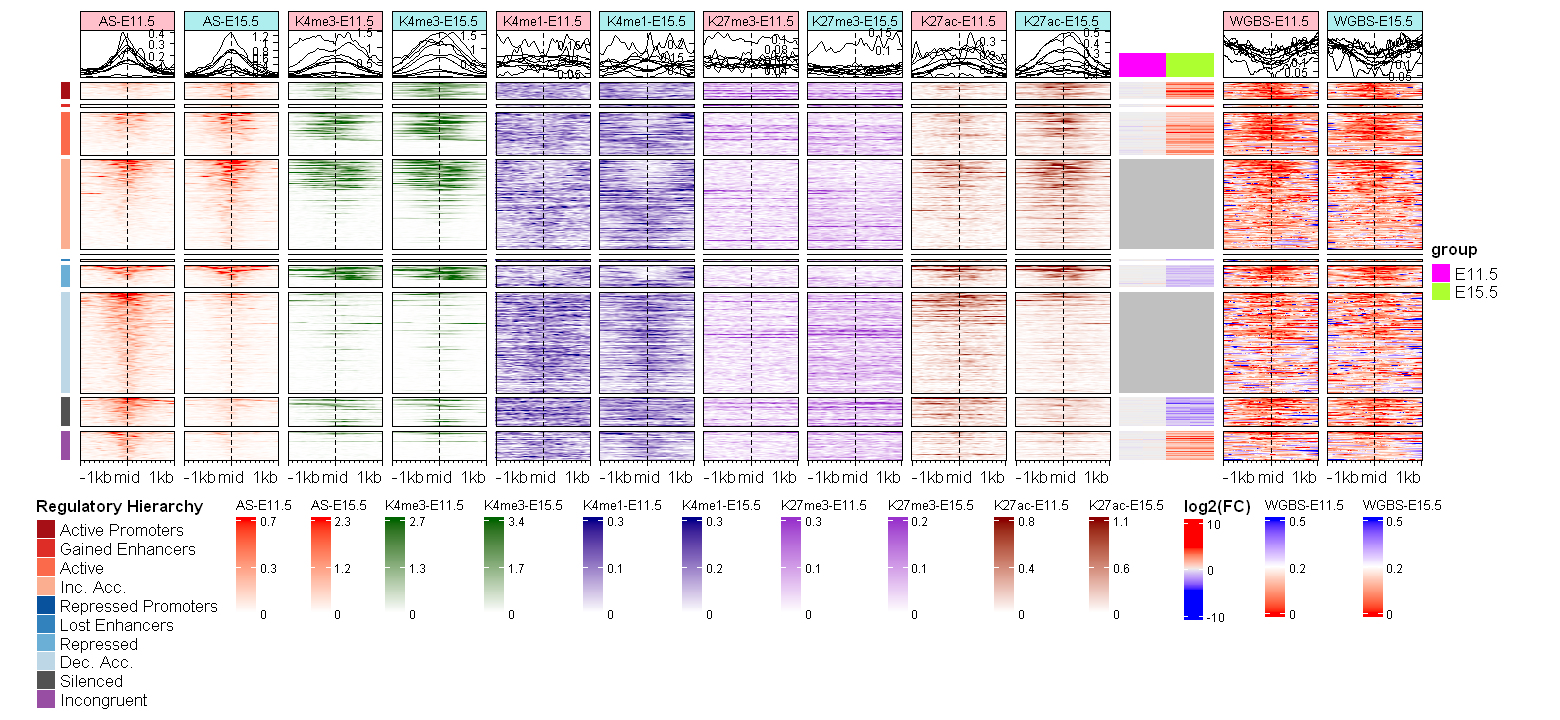

In [25]:
draw(composite_ht, split = split_multiomics, heatmap_legend_side = "bottom", merge_legend = FALSE)

### Exporting the composite figure

We will execute this rendering process twice to generate two different file types for two specific professional use cases:

1. **PDF Export:** A vector graphic that scales infinitely without ever losing resolution. This is the absolute gold standard for scientific publications.
2. **High-Res PNG Export:** A rasterized image (drawn at 330 dpi). Because massive multi-omics PDFs contain millions of individual vector data points, they can sometimes be slow to open or crash presentation software. Rendering a crisp PNG is the perfect, lightweight alternative for PowerPoint slides and fast web viewing. *(Notice we slightly increase the canvas dimensions for the PNG to ensure the rasterized text stays perfectly legible).*

Because a 14-column figure is incredibly dense, standard block borders will look too thick and cluttered. To fix this, we will use a clever `grid` graphics trick: `pushViewport(viewport(gp = gpar(lwd = 0.5)))`. This forces the global line width (`lwd`) of the entire drawing canvas to be razor-thin (`0.5`) *before* the heatmaps are drawn, giving our final exported figure a perfectly sharp, professional aesthetic.

In [26]:
# Open a PDF graphics device with explicit dimensions (in inches)
pdf(
  file = "output/final_heatmap.pdf", 
  width = 13, height = 6, 
)

# Create a fresh, blank canvas to draw on
grid.newpage()

# THE VIEWPORT TRICK: Force the global line width (lwd) to be razor-thin (0.5) 
# This prevents the borders of our 14 dense columns from looking cluttered
pushViewport(viewport(gp = gpar(lwd = 0.5)))

# Draw the final composite figure
draw(
  composite_ht, split = split_multiomics, heatmap_legend_side = "bottom", merge_legend = FALSE)

# Close the viewport (returning the global line width back to its normal default)
popViewport()

# Close the PDF device, which formally saves the rendered file to the hard drive
dev.off()

agg_record_5a3c6642682c 
                      2

In [27]:
# Open a PNG graphics device with tightly wrapped dimensions (in inches)
# We set res = 330 (dots per inch) to guarantee the raster image is sharp
png(
  filename = "output/final_heatmap.png", 
  width = 15, height = 7, units = "in", 
  res = 330)

# Create a fresh, blank canvas
grid.newpage()

# THE VIEWPORT TRICK: Force razor-thin line widths globally (lwd = 0.5)
pushViewport(viewport(gp = gpar(lwd = 0.5)))

# Draw the final composite figure
draw(
  composite_ht, split = split_multiomics, heatmap_legend_side = "bottom", merge_legend = FALSE)

# Close the viewport (returning line widths back to normal)
popViewport()

# Close the PNG device, formally saving the image to the hard drive
dev.off()

agg_record_5a3c5f0c4b73 
                      2

## Biological interpretation

### Validating "Active Promoters"

By looking horizontally across the top row of our massive composite figure, we can confidently confirm that our `Active Promoters` category is biologically accurate. The heatmap reveals a textbook multi-omics signature for active transcription start sites:

1. **Open Chromatin (ATAC):** A sharp, intense signal exactly at the center (0), representing the nucleosome-free region where transcription machinery is actively bound.
2. **The Promoter Hallmark (H3K4me3):** Massive, tightly centered enrichment. This is the universal, defining histone modification of an active promoter.
3. **Active Acetylation (H3K27ac):** High signal, often showing a slight "bimodal" dip at the very center (where the nucleosome is physically missing), flanking the ATAC peak.
4. **Absence of Repression (H3K27me3):** The track is completely blank (depleted), confirming that Polycomb repressive complexes are not silencing these genes.
5. **DNA Hypomethylation (WGBS):** The exact center of the peak is heavily depleted of methylation. The genome must keep these promoter regions completely unmethylated to maintain active transcription!
6. **Gene Expression (RNA-seq):** The RNA heatmap shows intense, positive expression, confirming that this open, actively modified chromatin structure successfully translates into transcribed genes.

This perfect, physical alignment across all 6 distinct biological assays proves that our `dplyr::case_when()` boolean logic successfully isolated true active promoters from the massive complexity of the genome.

### Validating "Repressed Promoters"

If we look at the dark blue `Repressed Promoters` track, we see the exact opposite biological signature:

1. **Polycomb Silencing (H3K27me3):** We see massive, broad enrichment of H3K27me3. This is the universal hallmark of Polycomb-mediated gene silencing.
2. **Chromatin Closure:** The ATAC-seq, H3K4me3, and H3K27ac tracks are almost completely barren. The chromatin is physically compacted and stripped of active modifications.
3. **Gene Silencing:** The RNA-seq track is distinctly blue (negative log2FC), proving that this heavy repressive chromatin structure effectively shuts down transcription.

### Validating "Lost Enhancers"

Enhancers have a completely different epigenetic signature than promoters. If we look at the light blue `Lost Enhancers` track, we can clearly see the dynamic process of an enhancer being decommissioned over developmental time:

1. **The Enhancer Hallmark (H3K4me1):** Unlike promoters, these regions are strongly enriched for H3K4me1 while being completely devoid of H3K4me3. This exact signature (High K4me1 + Low K4me3) is the classic mathematical rule used to separate enhancers from promoters!
2. **Dynamic Loss of Activity:** At E11.5, these regions have strong ATAC accessibility and H3K27ac (active acetylation). However, by E15.5, both the ATAC signal and the H3K27ac signal fade away as the enhancer is decommissioned.
3. **Target Gene Repression:** The RNA-seq track is blue, suggesting that as these specific enhancers lose their active state over time, the downstream genes they regulate are simultaneously downregulated.

### Validating the "Silenced" state (Hypermethylation)

Looking at the dark grey `Silenced` track near the bottom, we notice it is completely blank for ATAC, H3K4me3, and H3K27ac, and the gene expression is completely dead. But interestingly, it is *also* missing the Polycomb `H3K27me3` repressive mark! So how are these regions being kept shut? 

If we look at the far right, the **WGBS tracks are solid Red (hypermethylated)** across the entire 2kb window. This perfectly demonstrates that permanent silencing (heterochromatin) in the genome is often driven by massive DNA methylation rather than histone modifications.

### The Mystery of "Incongruent" elements

The purple `Incongruent` row at the very bottom represents regions where chromatin accessibility and gene expression move in *opposite* directions (e.g., the chromatin physically opens up, but the gene suddenly turns off). 

The most important takeaway here is how incredibly **thin** this row is compared to the main trajectories. This visually proves us that in biology, chromatin state and transcription are overwhelmingly tightly coupled. When they *do* decouple, it usually indicates complex secondary biology, such as a transcriptional repressor protein physically binding to that newly opened ATAC region, or the mRNA being degraded by microRNAs.